In [ ]:
# ============================================================
# RNN vs LSTM vs GRU for Sequence Classification
# ============================================================

# Numerical computing
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Time measurement
import time

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("=" * 60)
print("RNN vs LSTM vs GRU - Sequence Classification")
print("=" * 60)
print("TensorFlow Version :", tf.__version__)
print("NumPy Version      :", np.__version__)
print("=" * 60)

RNN vs LSTM vs GRU - Sequence Classification
TensorFlow Version : 2.20.0
NumPy Version      : 2.1.3


In [ ]:
# ============================================================
# Load IMDb Movie Review Dataset
# ============================================================

# Maximum number of words to keep
VOCAB_SIZE = 10000

# Maximum sequence length
MAX_LENGTH = 200

# Load IMDb dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(
    num_words=VOCAB_SIZE
)

print("Dataset loaded successfully!\n")

print("Training samples :", len(x_train))
print("Testing samples  :", len(x_test))

print("\nFirst review (encoded):")
print(x_train[0][:20])

print("\nFirst review label:")
print(y_train[0])

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset loaded successfully!

Training samples : 25000
Testing samples  : 25000

First review (encoded):
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]

First review label:
1


In [ ]:
# ============================================================
# Sequence Padding
# ============================================================

x_train = keras.utils.pad_sequences(
    x_train,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

x_test = keras.utils.pad_sequences(
    x_test,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("After padding:\n")

print("Training data shape :", x_train.shape)
print("Testing data shape  :", x_test.shape)

After padding:

Training data shape : (25000, 200)
Testing data shape  : (25000, 200)


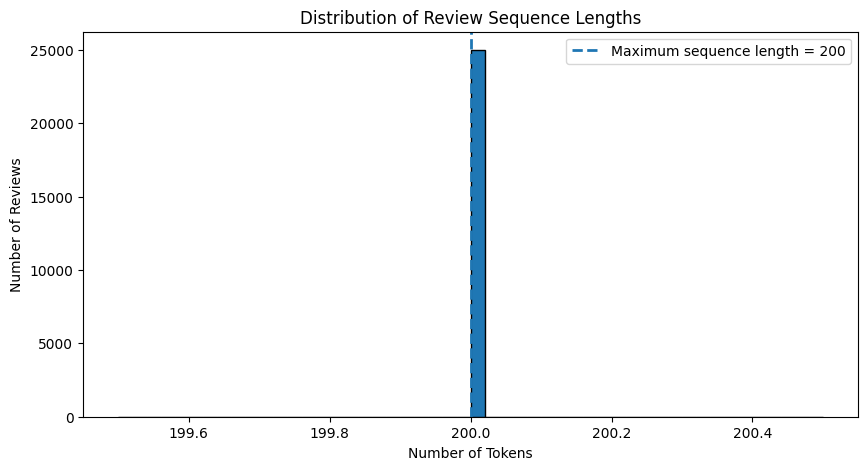

In [ ]:
# ============================================================
# Visualize Review Length Distribution
# ============================================================

# Calculate original review lengths
review_lengths = [len(review) for review in x_train]

plt.figure(figsize=(10, 5))

plt.hist(
    review_lengths,
    bins=50,
    edgecolor="black"
)

plt.axvline(
    MAX_LENGTH,
    linestyle="--",
    linewidth=2,
    label=f"Maximum sequence length = {MAX_LENGTH}"
)

plt.title("Distribution of Review Sequence Lengths")
plt.xlabel("Number of Tokens")
plt.ylabel("Number of Reviews")
plt.legend()
plt.show()

In [ ]:
# ============================================================
# Simple RNN Model
# ============================================================

def build_rnn_model():

    model = keras.Sequential([

        # Convert word IDs into dense vectors
        layers.Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=64
        ),

        # Simple Recurrent Neural Network
        layers.SimpleRNN(
            64
        ),

        # Reduce overfitting
        layers.Dropout(0.5),

        # Binary classification
        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


rnn_model = build_rnn_model()

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# Train Simple RNN
# ============================================================

start_time = time.time()

rnn_history = rnn_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=128,
    verbose=1
)

rnn_training_time = time.time() - start_time

print(f"\nRNN training time: {rnn_training_time:.2f} seconds")

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 20s 108ms/step - accuracy: 0.5032 - loss: 0.7000 - val_accuracy: 0.5104 - val_loss: 0.6930
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 99ms/step - accuracy: 0.5850 - loss: 0.6737 - val_accuracy: 0.4904 - val_loss: 0.7033
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 23s 115ms/step - accuracy: 0.6453 - loss: 0.6164 - val_accuracy: 0.4914 - val_loss: 0.7273
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 19s 106ms/step - accuracy: 0.7000 - loss: 0.5340 - val_accuracy: 0.4852 - val_loss: 0.8085
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 16s 102ms/step - accuracy: 0.7060 - loss: 0.5116 - val_accuracy: 0.4870 - val_loss: 0.8727

RNN training time: 98.15 seconds


In [ ]:
# ============================================================
# Evaluate Simple RNN
# ============================================================

rnn_probabilities = rnn_model.predict(
    x_test,
    verbose=0
).ravel()

rnn_predictions = (
    rnn_probabilities >= 0.5
).astype(int)

rnn_accuracy = accuracy_score(y_test, rnn_predictions)
rnn_precision = precision_score(y_test, rnn_predictions)
rnn_recall = recall_score(y_test, rnn_predictions)
rnn_f1 = f1_score(y_test, rnn_predictions)

print("\nRNN Performance")
print("=" * 40)
print(f"Accuracy  : {rnn_accuracy:.4f}")
print(f"Precision : {rnn_precision:.4f}")
print(f"Recall    : {rnn_recall:.4f}")
print(f"F1-Score  : {rnn_f1:.4f}")


RNN Performance
Accuracy  : 0.5046
Precision : 0.5047
Recall    : 0.4943
F1-Score  : 0.4995


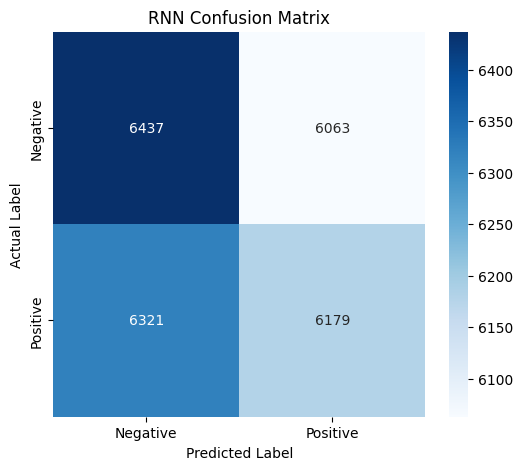

In [ ]:
# ============================================================
# RNN Confusion Matrix
# ============================================================

cm = confusion_matrix(
    y_test,
    rnn_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("RNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

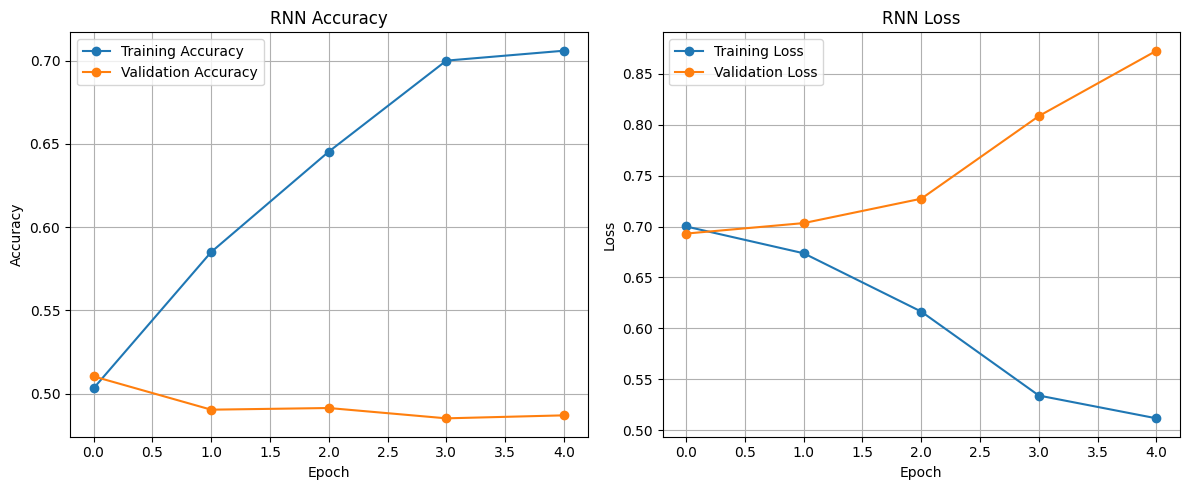

In [ ]:
# ============================================================
# RNN Training and Validation Curves
# ============================================================

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)

plt.plot(
    rnn_history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    rnn_history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("RNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)

plt.plot(
    rnn_history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    rnn_history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("RNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Step 10: Build LSTM Model
# ============================================================

def build_lstm_model():

    model = keras.Sequential([

        # Convert word indices into 64-dimensional vectors
        layers.Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=64
        ),

        # LSTM layer for learning long-term dependencies
        layers.LSTM(
            64
        ),

        # Reduce overfitting
        layers.Dropout(0.5),

        # Binary sentiment classification
        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    # Compile the model
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Create LSTM model
lstm_model = build_lstm_model()

# Display architecture
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# Step 11: Train LSTM Model
# ============================================================

start_time = time.time()

lstm_history = lstm_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=128,
    verbose=1
)

lstm_training_time = time.time() - start_time

print(f"\nLSTM Training Time: {lstm_training_time:.2f} seconds")

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 89s 528ms/step - accuracy: 0.5131 - loss: 0.6932 - val_accuracy: 0.5102 - val_loss: 0.6913
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 69s 442ms/step - accuracy: 0.5659 - loss: 0.6750 - val_accuracy: 0.5938 - val_loss: 0.6554
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 359ms/step - accuracy: 0.6133 - loss: 0.6391 - val_accuracy: 0.6882 - val_loss: 0.5879
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 81s 354ms/step - accuracy: 0.7635 - loss: 0.5333 - val_accuracy: 0.7600 - val_loss: 0.5815
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 357ms/step - accuracy: 0.7986 - loss: 0.4890 - val_accuracy: 0.6906 - val_loss: 0.6349

LSTM Training Time: 351.76 seconds


In [ ]:
# ============================================================
# Step 12: Evaluate LSTM Model
# ============================================================

# Generate prediction probabilities
lstm_probabilities = lstm_model.predict(
    x_test,
    verbose=0
).ravel()

# Convert probabilities into class labels
lstm_predictions = (
    lstm_probabilities >= 0.5
).astype(int)

# Calculate evaluation metrics
lstm_accuracy = accuracy_score(
    y_test,
    lstm_predictions
)

lstm_precision = precision_score(
    y_test,
    lstm_predictions
)

lstm_recall = recall_score(
    y_test,
    lstm_predictions
)

lstm_f1 = f1_score(
    y_test,
    lstm_predictions
)

print("=" * 45)
print("          LSTM PERFORMANCE")
print("=" * 45)

print(f"Accuracy      : {lstm_accuracy:.4f}")
print(f"Precision     : {lstm_precision:.4f}")
print(f"Recall        : {lstm_recall:.4f}")
print(f"F1-Score      : {lstm_f1:.4f}")
print(f"Training Time : {lstm_training_time:.2f} seconds")

          LSTM PERFORMANCE
Accuracy      : 0.6824
Precision     : 0.7157
Recall        : 0.6054
F1-Score      : 0.6559
Training Time : 351.76 seconds


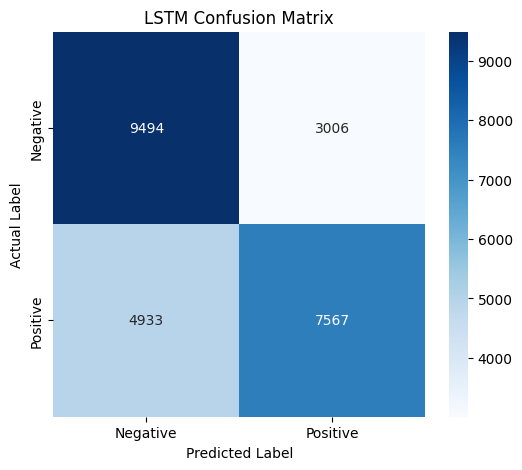

In [ ]:
# ============================================================
# Step 13: LSTM Confusion Matrix
# ============================================================

cm_lstm = confusion_matrix(
    y_test,
    lstm_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lstm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

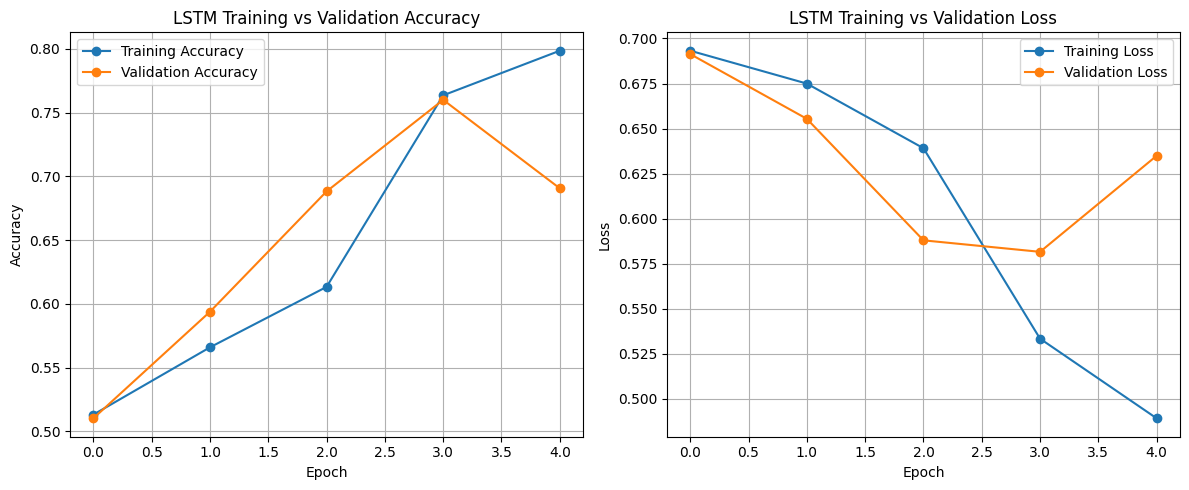

In [ ]:
# ============================================================
# Step 14: LSTM Training Curves
# ============================================================

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)

plt.plot(
    lstm_history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    lstm_history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("LSTM Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)

plt.plot(
    lstm_history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    lstm_history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Step 15: Build GRU Model
# ============================================================

def build_gru_model():

    model = keras.Sequential([

        # Convert word indices into 64-dimensional vectors
        layers.Embedding(
            input_dim=VOCAB_SIZE,
            output_dim=64
        ),

        # GRU layer for learning sequence dependencies
        layers.GRU(
            64
        ),

        # Reduce overfitting
        layers.Dropout(0.5),

        # Binary sentiment classification
        layers.Dense(
            1,
            activation="sigmoid"
        )
    ])

    # Compile the model
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


# Create GRU model
gru_model = build_gru_model()

# Display model architecture
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# Step 16: Train GRU Model
# ============================================================

start_time = time.time()

gru_history = gru_model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=128,
    verbose=1
)

gru_training_time = time.time() - start_time

print(f"\nGRU Training Time: {gru_training_time:.2f} seconds")

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 65s 385ms/step - accuracy: 0.5084 - loss: 0.6931 - val_accuracy: 0.5198 - val_loss: 0.6917
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 368ms/step - accuracy: 0.5696 - loss: 0.6908 - val_accuracy: 0.5342 - val_loss: 0.6876
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 380ms/step - accuracy: 0.6048 - loss: 0.6495 - val_accuracy: 0.6306 - val_loss: 0.6479
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 373ms/step - accuracy: 0.7310 - loss: 0.5575 - val_accuracy: 0.5972 - val_loss: 0.6620
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 85s 390ms/step - accuracy: 0.7424 - loss: 0.5531 - val_accuracy: 0.7302 - val_loss: 0.6174

GRU Training Time: 346.66 seconds


In [ ]:
# ============================================================
# Step 17: Evaluate GRU Model
# ============================================================

# Generate prediction probabilities
gru_probabilities = gru_model.predict(
    x_test,
    verbose=0
).ravel()

# Convert probabilities into class labels
gru_predictions = (
    gru_probabilities >= 0.5
).astype(int)

# Calculate evaluation metrics
gru_accuracy = accuracy_score(
    y_test,
    gru_predictions
)

gru_precision = precision_score(
    y_test,
    gru_predictions
)

gru_recall = recall_score(
    y_test,
    gru_predictions
)

gru_f1 = f1_score(
    y_test,
    gru_predictions
)

print("=" * 45)
print("           GRU PERFORMANCE")
print("=" * 45)

print(f"Accuracy      : {gru_accuracy:.4f}")
print(f"Precision     : {gru_precision:.4f}")
print(f"Recall        : {gru_recall:.4f}")
print(f"F1-Score      : {gru_f1:.4f}")
print(f"Training Time : {gru_training_time:.2f} seconds")

           GRU PERFORMANCE
Accuracy      : 0.7354
Precision     : 0.6770
Recall        : 0.9005
F1-Score      : 0.7729
Training Time : 346.66 seconds


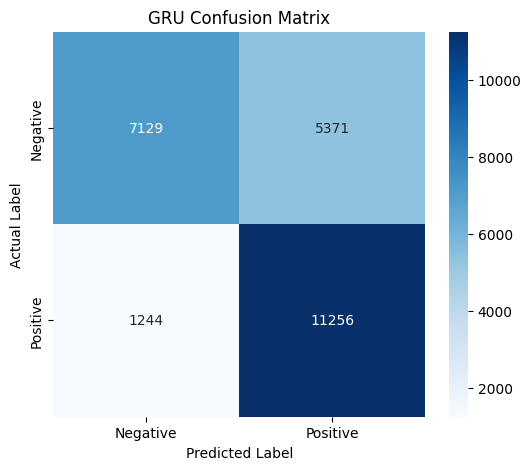

In [ ]:
# ============================================================
# Step 18: GRU Confusion Matrix
# ============================================================

cm_gru = confusion_matrix(
    y_test,
    gru_predictions
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_gru,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.title("GRU Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

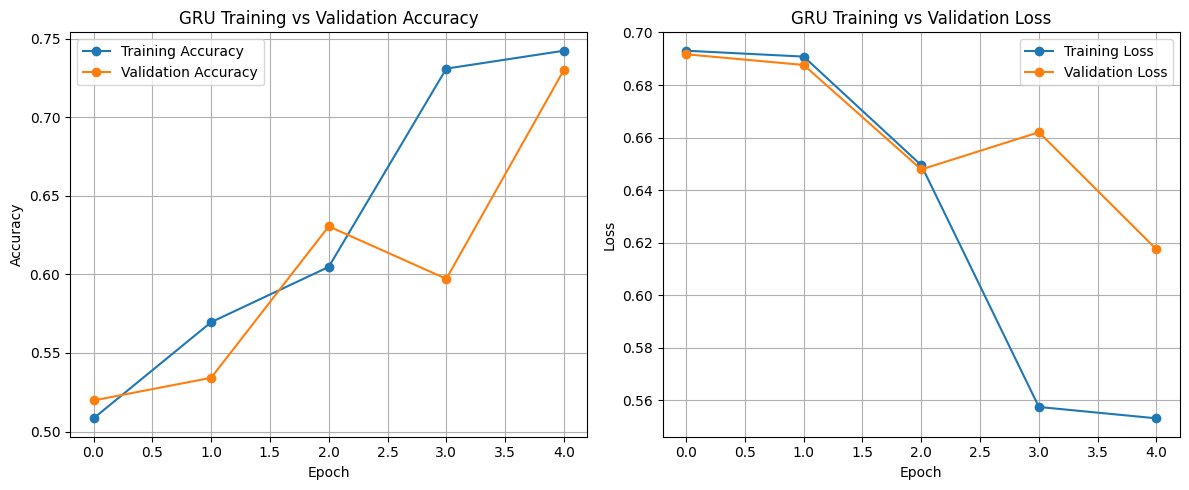

In [ ]:
# ============================================================
# Step 19: GRU Training Curves
# ============================================================

plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)

plt.plot(
    gru_history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    gru_history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("GRU Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)

plt.plot(
    gru_history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    gru_history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("GRU Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Step 20: Compare RNN, LSTM and GRU
# ============================================================

results = {
    "Model": [
        "Simple RNN",
        "LSTM",
        "GRU"
    ],

    "Accuracy": [
        rnn_accuracy,
        lstm_accuracy,
        gru_accuracy
    ],

    "Precision": [
        rnn_precision,
        lstm_precision,
        gru_precision
    ],

    "Recall": [
        rnn_recall,
        lstm_recall,
        gru_recall
    ],

    "F1-Score": [
        rnn_f1,
        lstm_f1,
        gru_f1
    ],

    "Training Time (sec)": [
        rnn_training_time,
        lstm_training_time,
        gru_training_time
    ]
}

results_df = pd.DataFrame(results)

# Round numerical values
results_df = results_df.round(4)

print("\nFINAL MODEL COMPARISON")
print("=" * 80)

display(results_df)

NameError: name 'pd' is not defined

In [ ]:
import pandas as pd

In [ ]:
# ============================================================
# Step 20: Compare RNN, LSTM and GRU
# ============================================================

results = {
    "Model": [
        "Simple RNN",
        "LSTM",
        "GRU"
    ],

    "Accuracy": [
        rnn_accuracy,
        lstm_accuracy,
        gru_accuracy
    ],

    "Precision": [
        rnn_precision,
        lstm_precision,
        gru_precision
    ],

    "Recall": [
        rnn_recall,
        lstm_recall,
        gru_recall
    ],

    "F1-Score": [
        rnn_f1,
        lstm_f1,
        gru_f1
    ],

    "Training Time (sec)": [
        rnn_training_time,
        lstm_training_time,
        gru_training_time
    ]
}

results_df = pd.DataFrame(results)

# Round numerical values
results_df = results_df.round(4)

print("\nFINAL MODEL COMPARISON")
print("=" * 80)

display(results_df)


FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1-Score,Training Time (sec)
0,Simple RNN,0.5046,0.5047,0.4943,0.4995,98.151
1,LSTM,0.6824,0.7157,0.6054,0.6559,351.756
2,GRU,0.7354,0.6770,0.9005,0.7729,346.656


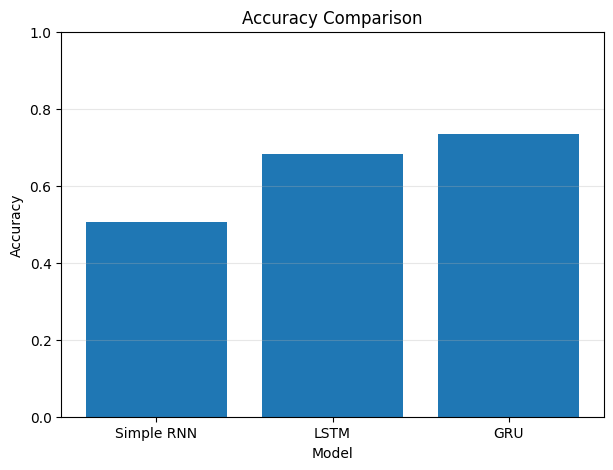

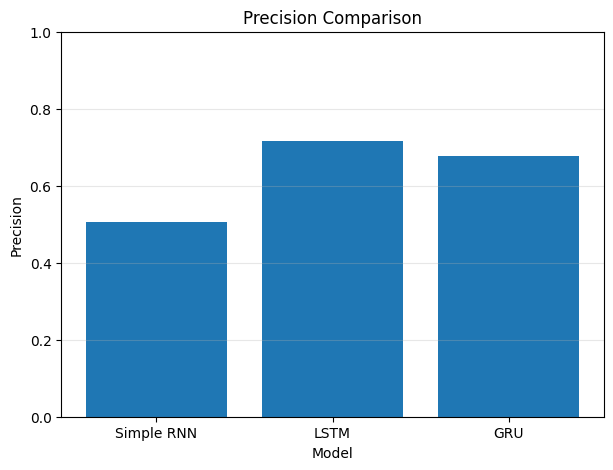

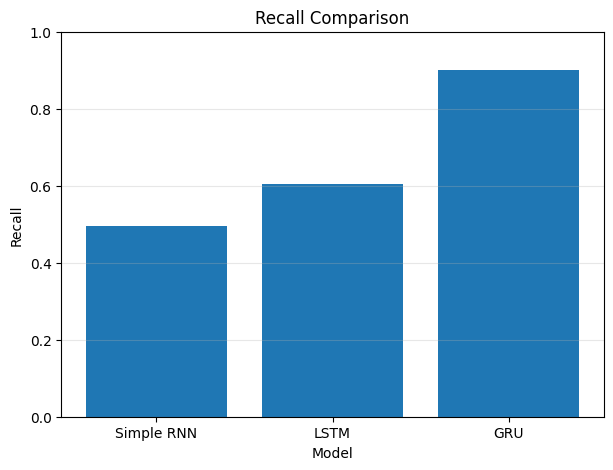

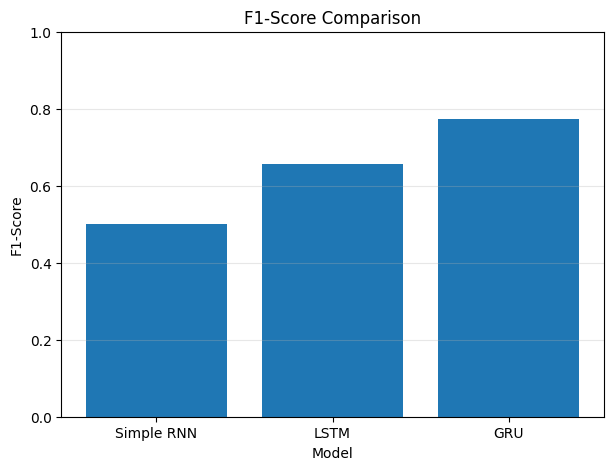

In [ ]:
# ============================================================
# Step 21: Model Performance Comparison
# ============================================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]

for metric in metrics:

    plt.figure(figsize=(7, 5))

    plt.bar(
        results_df["Model"],
        results_df[metric]
    )

    plt.title(f"{metric} Comparison")
    plt.xlabel("Model")
    plt.ylabel(metric)

    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)

    plt.show()

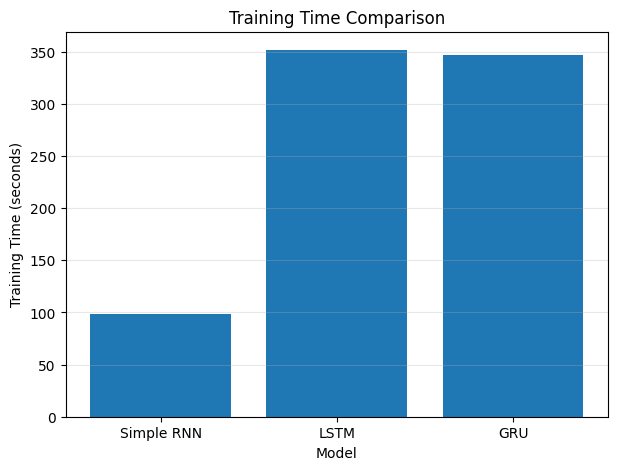

In [ ]:
# ============================================================
# Step 22: Training Time Comparison
# ============================================================

plt.figure(figsize=(7, 5))

plt.bar(
    results_df["Model"],
    results_df["Training Time (sec)"]
)

plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time (seconds)")

plt.grid(axis="y", alpha=0.3)

plt.show()